#Libraries and packages

In [103]:
# Logistic Classification
# STP
# 15/04/24
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [104]:
#upload files or mount google drive unit
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')
#uploaded = files.upload()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data cleaning and exploratory analysis

In [90]:
df=pd.read_csv("/content/drive/MyDrive/Mineria de Datos/Homeworks/Logistic Classification/Affairs.csv")
df

,Unnamed: 0,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
0,4,0,male,37.0,10.00,no,3,18,7,4
1,5,0,female,27.0,4.00,no,4,14,6,4
2,11,0,female,32.0,15.00,yes,1,12,1,4
3,16,0,male,57.0,15.00,yes,5,18,6,5
4,23,0,male,22.0,0.75,no,2,17,6,3
...,...,...,...,...,...,...,...,...,...,...
596,1938,1,male,22.0,1.50,yes,1,12,2,5
597,1941,7,female,32.0,10.00,yes,2,18,5,4
598,1954,2,male,32.0,10.00,yes,2,17,6,5
599,1959,2,male,22.0,7.00,yes,3,18,6,2


In [91]:
df.shape

(601, 10)

In [92]:
# Selecting only female attributes in gender column
df_01 = df.copy()
df_01 = df_01[df_01['gender'] != 'male']
print(df_01.shape)
df_01

(315, 10)


,Unnamed: 0,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
1,5,0,female,27.0,4.00,no,4,14,6,4
2,11,0,female,32.0,15.00,yes,1,12,1,4
5,29,0,female,32.0,1.50,no,2,17,5,5
6,44,0,female,22.0,0.75,no,2,12,1,3
8,47,0,female,32.0,15.00,yes,4,16,1,2
...,...,...,...,...,...,...,...,...,...,...
589,1831,7,female,32.0,15.00,yes,3,14,3,2
590,1840,7,female,27.0,7.00,yes,4,16,1,2
592,1856,7,female,42.0,15.00,yes,2,14,3,2
597,1941,7,female,32.0,10.00,yes,2,18,5,4


The data frame has been cut in half with female attribute in gender feature. We are going to drop some features for convenience in the process of regression.

In [93]:
df_01=df_01.drop(columns=['gender','Unnamed: 0'])
df_01

,affairs,age,yearsmarried,children,religiousness,education,occupation,rating
1,0,27.0,4.00,no,4,14,6,4
2,0,32.0,15.00,yes,1,12,1,4
5,0,32.0,1.50,no,2,17,5,5
6,0,22.0,0.75,no,2,12,1,3
8,0,32.0,15.00,yes,4,16,1,2
...,...,...,...,...,...,...,...,...
589,7,32.0,15.00,yes,3,14,3,2
590,7,27.0,7.00,yes,4,16,1,2
592,7,42.0,15.00,yes,2,14,3,2
597,7,32.0,10.00,yes,2,18,5,4


In [94]:
df_01.describe()

,affairs,age,yearsmarried,religiousness,education,occupation,rating
count,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000
mean,1.419048,30.801587,8.017070,3.107937,15.257143,3.384127,3.939683
std,3.309264,8.646241,5.627237,1.134758,2.023879,1.929094,1.148045
min,0.000000,17.500000,0.125000,1.000000,9.000000,1.000000,1.000000
25%,0.000000,22.000000,1.500000,2.000000,14.000000,1.000000,3.000000
50%,0.000000,27.000000,7.000000,3.000000,16.000000,4.000000,4.000000
75%,0.000000,37.000000,15.000000,4.000000,17.000000,5.000000,5.000000
max,12.000000,57.000000,15.000000,5.000000,20.000000,7.000000,5.000000


In [95]:
df_01.info()

<class 'pandas.core.frame.DataFrame'>
Index: 315 entries, 1 to 600
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   affairs        315 non-null    int64  
 1   age            315 non-null    float64
 2   yearsmarried   315 non-null    float64
 3   children       315 non-null    object 
 4   religiousness  315 non-null    int64  
 5   education      315 non-null    int64  
 6   occupation     315 non-null    int64  
 7   rating         315 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 22.1+ KB


Number of observations: 6366
Number of variables: 9
Variable name definitions:

    rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair, 4 = good, 5 = very good
    age             : Age
    years_married   : Number of years married. Interval approximations.
    children        : Number of children
    religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly, 4 = strongly
    educ            : Level of education, 9 = grade school, 12 = high-school, 14 = some college, 16 = college graduate, 17 = some graduate school, 20 = advanced degree
    occupation      : 1 = student, 2 = farming, agriculture; semi-skilled, or unskilled worker; 3 = white-colloar; 4 = teacher counselor social worker, nurse; artist, writers; technician, skilled worker, 5 = managerial, administrative, business, 6 = professional with advanced degree
    occupation_husb : Husband's occupation. Same as occupation.
    affairs         : measure of time spent in extramarital affairs

See the original paper for more details.


The children feature has object data type instead of numeric. With `.replace()` we can change the data type.

In [96]:
df_02 = df_01.copy()
df_02 = df_02.replace({'yes': 1, 'no': 0})
print('affairs: ', df_02['affairs'].unique())
print('age: ', df_02['age'].unique())
print('years married: ', df_02['yearsmarried'].unique())
print('children: ', df_02['children'].unique())
print('religiousness: ', df_02['religiousness'].unique())
print('education: ', df_02['education'].unique())
print('occupation: ', df_02['occupation'].unique())
print('rating: ', df_02['rating'].unique())
df_02

affairs:  [ 0  3 12  1  7  2]
age:  [27.  32.  22.  37.  42.  47.  52.  57.  17.5]
years married:  [ 4.    15.     1.5    0.75  10.     7.     0.417  0.125]
children:  [0 1]
religiousness:  [4 1 2 3 5]
education:  [14 12 17 16 18  9 20]
occupation:  [6 1 5 4 3 7 2]
rating:  [4 5 3 2 1]


,affairs,age,yearsmarried,children,religiousness,education,occupation,rating
1,0,27.0,4.00,0,4,14,6,4
2,0,32.0,15.00,1,1,12,1,4
5,0,32.0,1.50,0,2,17,5,5
6,0,22.0,0.75,0,2,12,1,3
8,0,32.0,15.00,1,4,16,1,2
...,...,...,...,...,...,...,...,...
589,7,32.0,15.00,1,3,14,3,2
590,7,27.0,7.00,1,4,16,1,2
592,7,42.0,15.00,1,2,14,3,2
597,7,32.0,10.00,1,2,18,5,4


Since affair was measured in terms of time, all the numeric values except 0 in this feature can be replaced by 1, reducing the regression process.

In [97]:
df_03 = df_02.copy()
df_03 = df_03.reset_index(drop=True)    # Resets data frame index and deletes the old one
df_03['affairs'] = df_03['affairs'].astype(str)   # Converts the numeric data in string data to easily manipulates the df affairs column
df_03['affairs'] = df_03['affairs'].replace(['3', '12', '7', '2'], '1')
df_03['affairs'] = df_03['affairs'].astype(np.int64)
print(df_03['affairs'].unique())
df_03

[0 1]


,affairs,age,yearsmarried,children,religiousness,education,occupation,rating
0,0,27.0,4.00,0,4,14,6,4
1,0,32.0,15.00,1,1,12,1,4
2,0,32.0,1.50,0,2,17,5,5
3,0,22.0,0.75,0,2,12,1,3
4,0,32.0,15.00,1,4,16,1,2
...,...,...,...,...,...,...,...,...
310,1,32.0,15.00,1,3,14,3,2
311,1,27.0,7.00,1,4,16,1,2
312,1,42.0,15.00,1,2,14,3,2
313,1,32.0,10.00,1,2,18,5,4


# Logistic Binary Classification

In [98]:
# Splitting data 70 - 30 (train - test)
x = df_03.iloc[:,[1, 2, 3, 4, 5, 6, 7]].values    # Features excluding affairs
y = df_03.iloc[:,0].values    # Real data for affairs
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.7, random_state = 0, shuffle= True)
standard_x = StandardScaler()
x_train = standard_x.fit_transform(x_train)
x_test = standard_x.fit_transform(x_test)
reg = LogisticRegression(random_state=0).fit(x_train[:, :2], y_train)   # Logistic regression with scikit-learn
reg.fit(x_train, y_train)

LogisticRegression(random_state=0)

Prediction for train data

In [99]:
# Prediction for affairs from train part
P = reg.predict(x_train)
print("Accuracy:", accuracy_score(y_train, P))
print("Precision:", precision_score(y_train, P, pos_label = 1))
confusion = confusion_matrix(y_train, P)
confusion

Accuracy: 0.7909090909090909
Precision: 0.631578947368421


array([[162,   7],
       [ 39,  12]])

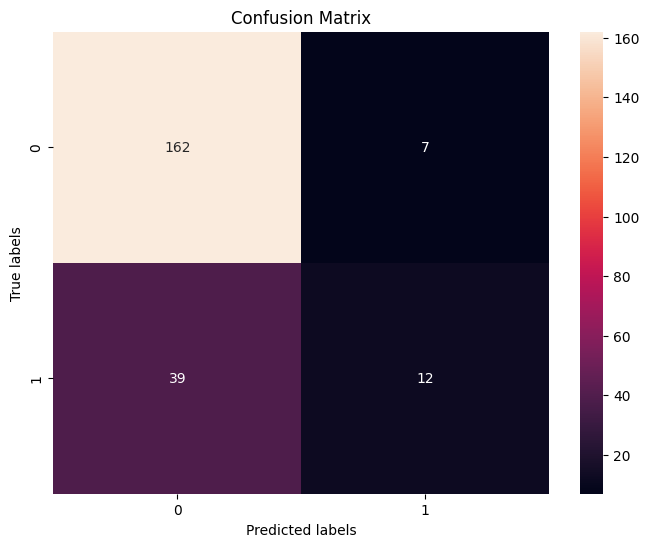

In [100]:
# Heat map to plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

Prediction for test data

In [101]:
# Prediction on test data
P = reg.predict(x_test)
print("Accuracy:", accuracy_score(y_test, P))
print("Precision:", precision_score(y_test, P, pos_label = 1))
confusion = confusion_matrix(y_test, P)
print("Confusion Matrix:")
print(confusion)

Accuracy: 0.7368421052631579
Precision: 0.16666666666666666
Confusion Matrix:
[[69  5]
 [20  1]]


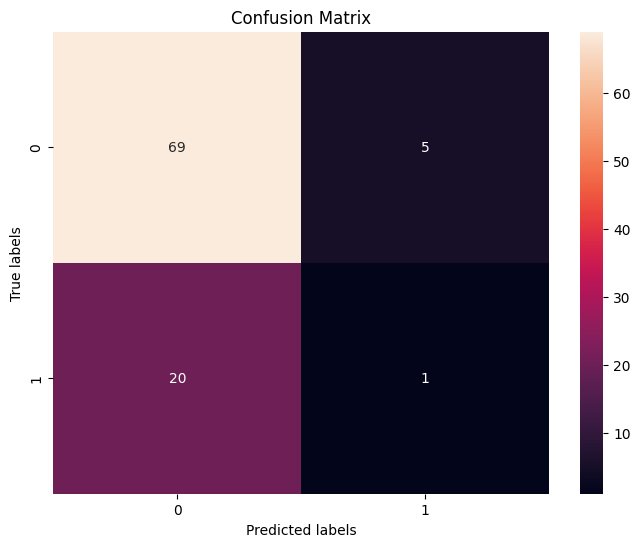

In [102]:
# Heat map to plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()